In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


In [3]:
import os
import pandas as pd

FRAMES_DIR = "../02_media/stratified_sample/frames"

frame_counts = []

for video_id in os.listdir(FRAMES_DIR):
    video_path = os.path.join(FRAMES_DIR, video_id)
    if os.path.isdir(video_path):
        n_frames = len([
            f for f in os.listdir(video_path)
            if os.path.isfile(os.path.join(video_path, f))
        ])
        frame_counts.append((video_id, n_frames))

df_frames = pd.DataFrame(frame_counts, columns=["video_id", "n_frames"])

df_frames.describe()

FileNotFoundError: [Errno 2] No such file or directory: '../02_media/stratified_sample/frames'

In [ ]:
videos_stratified = pd.read_csv("../03_datasets/influencer_balanced/01_AI_AND_REAL_TIKTOK_VIDEOS_stratified_per_influencer_50.csv")
videos_stratified.groupby(["influencer_type", "author_username"]).size()

comments_stratified = pd.read_csv("../03_datasets/influencer_balanced/02_AI_AND_REAL_TIKTOK_COMMENTS_FOR_STRATIFIED_VIDEOS.csv")
comments_stratified.groupby(["influencer_type", "influencer"]).size()

influencer_type  author_username    
ai               ai.kalai               50
                 brexleyai              50
                 imma.tokyo             50
                 lilmiquela             50
                 millas_sofia           50
real             ericanic0le            50
                 hollybrandmusic        50
                 jessicawangofficial    50
                 misshannahashton       50
                 nobodywhoareu          50
dtype: int64


influencer_type  influencer         
ai               ai.kalai                801
                 brexleyai               448
                 imma.tokyo             1428
                 lilmiquela             7198
                 millas_sofia            783
real             ericanic0le            2443
                 hollybrandmusic         140
                 jessicawangofficial     127
                 misshannahashton        668
                 nobodywhoareu          2994
dtype: int64

In [3]:
videos = pd.read_csv("../01_raw/videos_metadata/01_AI_AND_REAL_TIKTOK_VIDEOS_DATASET_2025.csv")
comments = pd.read_csv("../01_raw/comments_metadata/02_AI_AND_REAL_TIKTOK_COMMENTS_DATASET_2025.csv")

videos.head(), comments.head()


(              video_id      video_thread_id author_username  \
 0  7516032103390203178  7516032103390203178        ai.kalai   
 1  7517830042206899469  7517830042206899469        ai.kalai   
 2  7516243181650988334  7516243181650988334        ai.kalai   
 3  7516395955562859819  7516395955562859819        ai.kalai   
 4  7518222079955602743  7518222079955602743        ai.kalai   
 
   author_displayname  author_follower_count  author_like_count_total  \
 0           kalai.ai                   9773                       20   
 1           kalai.ai                   9773                       20   
 2           kalai.ai                   9773                       20   
 3           kalai.ai                   9773                       20   
 4           kalai.ai                   9773                       20   
 
    author_video_count                                  author_avatar_url  \
 0                  55  https://p16-sign-va.tiktokcdn.com/tos-maliva-a...   
 1                  

In [3]:
print("Videos:", videos.shape)
print("Kommentare:", comments.shape)

videos["influencer_type"].value_counts(), comments["influencer_type"].value_counts()

Videos: (1035, 42)
Kommentare: (39579, 20)


(influencer_type
 real    733
 ai      302
 Name: count, dtype: int64,
 influencer_type
 real    24512
 ai      15067
 Name: count, dtype: int64)

In [4]:
videos.groupby(["influencer_type", "author_username"]).size()

influencer_type  author_username    
ai               ai.kalai                55
                 brexleyai               53
                 imma.tokyo              50
                 lilmiquela              91
                 millas_sofia            53
real             ericanic0le            205
                 hollybrandmusic         93
                 jessicawangofficial     93
                 misshannahashton       145
                 nobodywhoareu          197
dtype: int64

In [5]:
videos.groupby("influencer_type")[
    ["video_view_count", "video_like_count", "video_comment_count", "video_share_count", "video_engagement_rate"]
].describe()

video_view_count                                              \
                           count          mean           std     min     25%   
influencer_type                                                                
ai                         302.0  698984.00000  2.174563e+06  1941.0  9947.5   
real                       733.0  177044.26603  9.963336e+05   232.0  1876.0   

                                               video_like_count                \
                     50%       75%         max            count          mean   
influencer_type                                                                 
ai               71450.0  579275.0  21000000.0            302.0  53010.023179   
real              7948.0   33800.0  13500000.0            733.0   6280.499318   

                 ... video_share_count          video_engagement_rate  \
                 ...               75%      max                 count   
influencer_type  ...                                                    
ai               ...            148.75  16600.0                 302.0   
real             ...             25.00  18000.0                 733.0   

                                                                             \
                     mean       std       min       25%       50%       75%   
influencer_type                                                               
ai               0.041073  0.038221  0.000954  0.010986  0.025858  0.059878   
real             0.047771  0.031339  0.000795  0.026145  0.042299  0.060937   

                           
                      max  
influencer_type            
ai               0.186101  
real             0.247293  

[2 rows x 40 columns]

<Figure size 800x500 with 0 Axes>

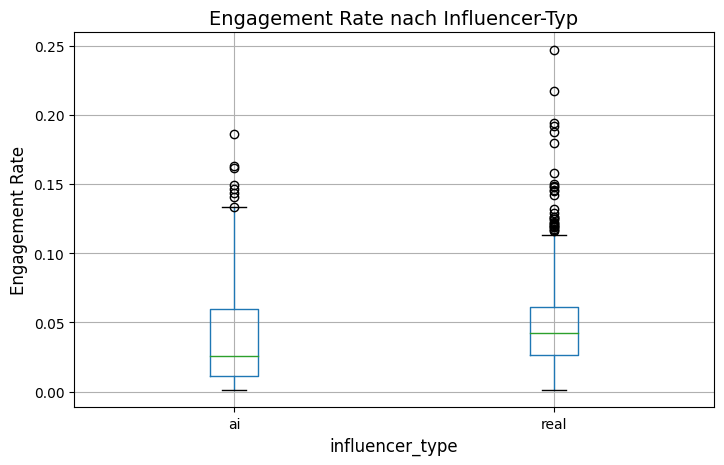

In [6]:
plt.figure()
videos.boxplot(
    column="video_engagement_rate",
    by="influencer_type"
)
plt.title("Engagement Rate nach Influencer-Typ")
plt.suptitle("")
plt.ylabel("Engagement Rate")
plt.show()


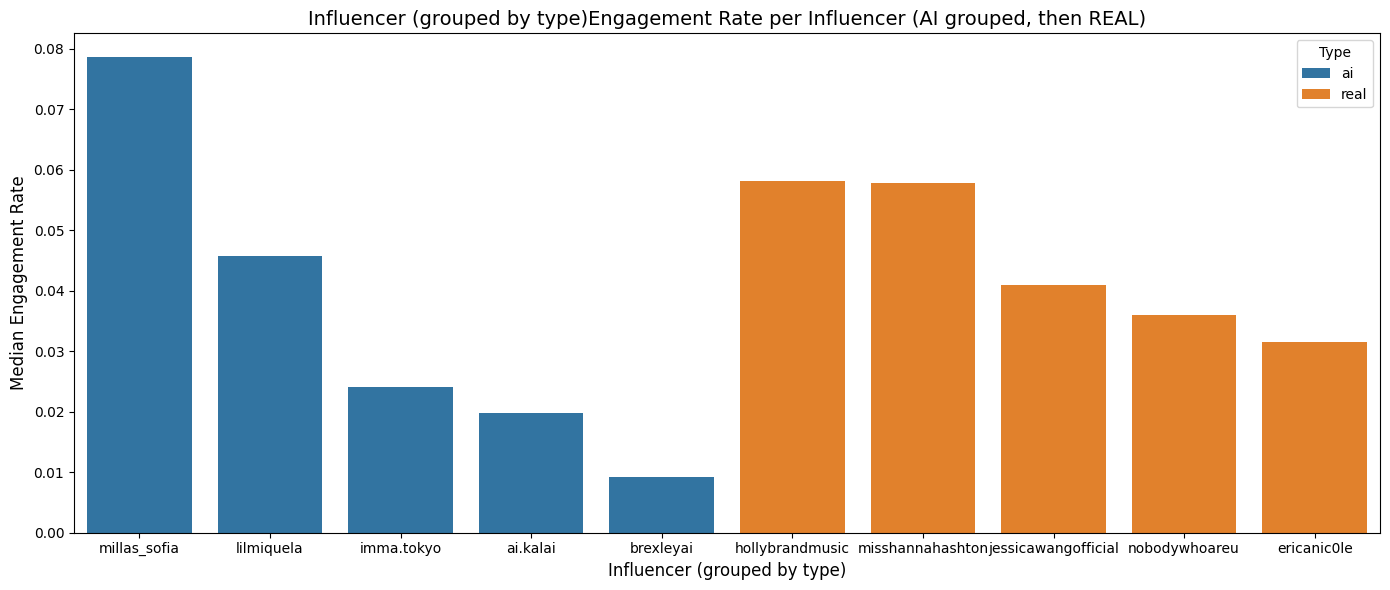

In [14]:
# Pro Influencerin aggregieren
agg = (
    videos.groupby(["influencer_type", "influencer"], dropna=False)
      .agg(
          median_er=("video_engagement_rate", "median"),
          mean_er=("video_engagement_rate", "mean"),
          n_videos=("video_id", "count")
      )
      .reset_index()
)

# Erst KI, dann Real; innerhalb der Gruppen nach Median sortieren
type_order = ["ai", "real"]
agg["influencer_type"] = pd.Categorical(agg["influencer_type"], categories=type_order, ordered=True)
agg = agg.sort_values(["influencer_type", "median_er"], ascending=[True, False]).reset_index(drop=True)

# Eindeutige Y-Labels f?r stabile Sortierung
agg["label"] = agg["influencer"].astype(str)

plt.figure(figsize=(14, max(6, 0.35 * len(agg))))
sns.barplot(
    data=agg,
    x="label",
    y="median_er",
    hue="influencer_type",
    dodge=False
)
plt.xlabel("Influencer (grouped by type)")
plt.ylabel("Median Engagement Rate")
plt.title("Influencer (grouped by type)Engagement Rate per Influencer (AI grouped, then REAL)")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

In [4]:
# Numerische ?bersicht pro Influencerin
table = (
    videos.groupby(["influencer_type", "influencer"], dropna=False)
      .agg(
          n_videos=("video_id", "count"),
          median_engagement_rate=("video_engagement_rate", "median"),
          mean_engagement_rate=("video_engagement_rate", "mean"),
          std_engagement_rate=("video_engagement_rate", "std"),
          min_engagement_rate=("video_engagement_rate", "min"),
          max_engagement_rate=("video_engagement_rate", "max"),
      )
      .reset_index()
)

# Erst KI, dann Real; innerhalb der Gruppen nach Median sortieren
table["influencer_type"] = pd.Categorical(
    table["influencer_type"], categories=["ai", "real"], ordered=True
)
table = table.sort_values(
    ["influencer_type", "median_engagement_rate"],
    ascending=[True, False]
).reset_index(drop=True)

# F?r die Anzeige runden
table_rounded = table.copy()
num_cols = [c for c in table_rounded.columns if "engagement_rate" in c]
table_rounded[num_cols] = table_rounded[num_cols].round(4)

table_rounded

,influencer_type,influencer,n_videos,median_engagement_rate,mean_engagement_rate,std_engagement_rate,min_engagement_rate,max_engagement_rate
0,ai,millas_sofia,53,0.0786,0.0797,0.0327,0.0095,0.1628
1,ai,lilmiquela,91,0.0458,0.0511,0.0389,0.0010,0.1615
2,ai,imma.tokyo,50,0.0240,0.0321,0.0301,0.0034,0.1491
3,ai,ai.kalai,55,0.0197,0.0256,0.0290,0.0068,0.1861
4,ai,brexleyai,53,0.0092,0.0098,0.0051,0.0025,0.0281
5,real,hollybrandmusic,93,0.0581,0.0605,0.0252,0.0193,0.1455
6,real,misshannahashton,145,0.0577,0.0647,0.0333,0.0009,0.1918
7,real,jessicawangofficial,93,0.0410,0.0436,0.0247,0.0008,0.1128
8,real,nobodywhoareu,197,0.0360,0.0384,0.0210,0.0060,0.1500
9,real,ericanic0le,205,0.0315,0.0410,0.0366,0.0008,0.2473


Kommentare

In [44]:
comments.groupby("influencer_type")["comment_like_count"].describe()


,count,mean,std,min,25%,50%,75%,max
influencer_type,,,,,,,,
ai,7918.0,31.928265,515.604722,0.0,0.0,0.0,1.0,26973.0
real,11872.0,62.337517,1407.597848,0.0,0.0,0.0,1.0,97354.0


<Figure size 800x500 with 0 Axes>

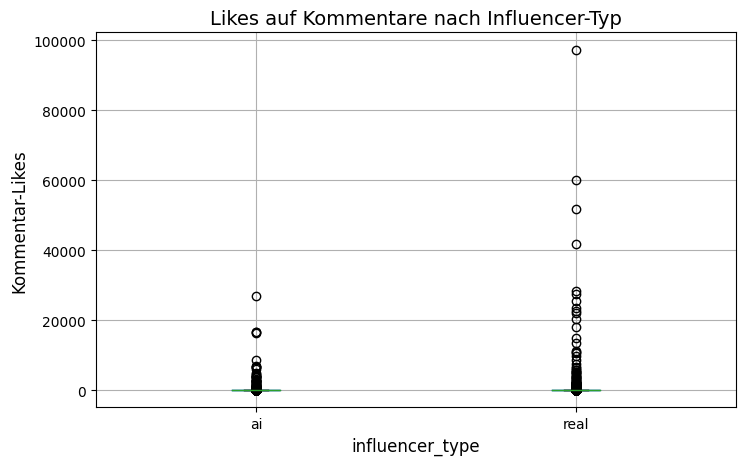

In [45]:
plt.figure()
comments.boxplot(
    column="comment_like_count",
    by="influencer_type"
)
plt.title("Likes auf Kommentare nach Influencer-Typ")
plt.suptitle("")
plt.ylabel("Kommentar-Likes")
plt.show()
